### Visualisation to Support Analysis of Data Quality

Connect notebook to project root

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
#import libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.database.query import (
    salary_distribution,
    top_employers,
    top_locations,
    jobs_by_contract_type,
    salary_statistics,
    salary_outliers,
    list_salary_outliers,
)

#### Analysis of salary distribution 

In [3]:
df_salary = pd.DataFrame(salary_distribution())
df_salary.head()

,salary_range,jobs
0,£0.0k–£19.0k,1013
1,£20.0k–£39.0k,7658
2,£40.0k–£59.0k,2088
3,£60.0k–£79.0k,8385
4,£80.0k–£99.0k,896


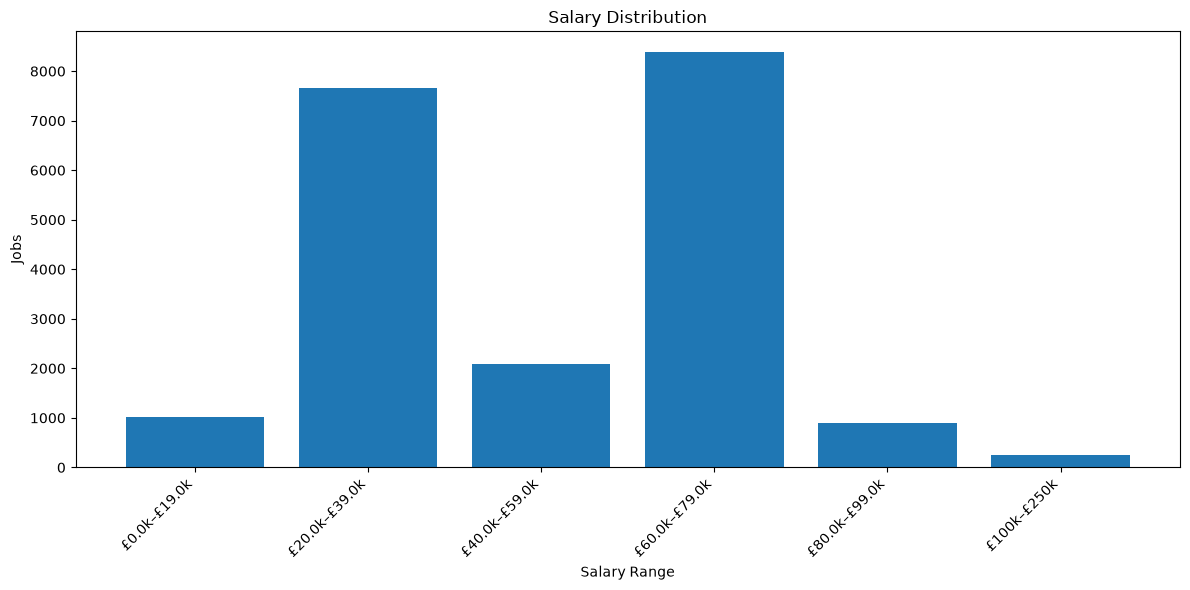

In [4]:
# Salary Distribution Bar Chart
plt.figure(figsize=(12, 6))

plt.bar(
    df_salary["salary_range"],
    df_salary["jobs"],
)

plt.title("Salary Distribution")
plt.xlabel("Salary Range")
plt.ylabel("Jobs")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

This chart shows a clear distribution with clear pay ranges for junior/ senior positions.
it should be noted that outlier salaries (over 250k) are excluded as they are believed to be largely erroneous.

In [16]:
df_employers = pd.DataFrame(top_employers())
df_employers.head()

,organisation,jobs
0,Central Advertising - General Practitioners,1887
1,King's College Hospital NHS Foundation Trust,477
2,Barts Health NHS Trust,379
3,Guy's and St. Thomas' NHS Foundation Trust,316
4,Manchester University NHS Foundation Trust,313


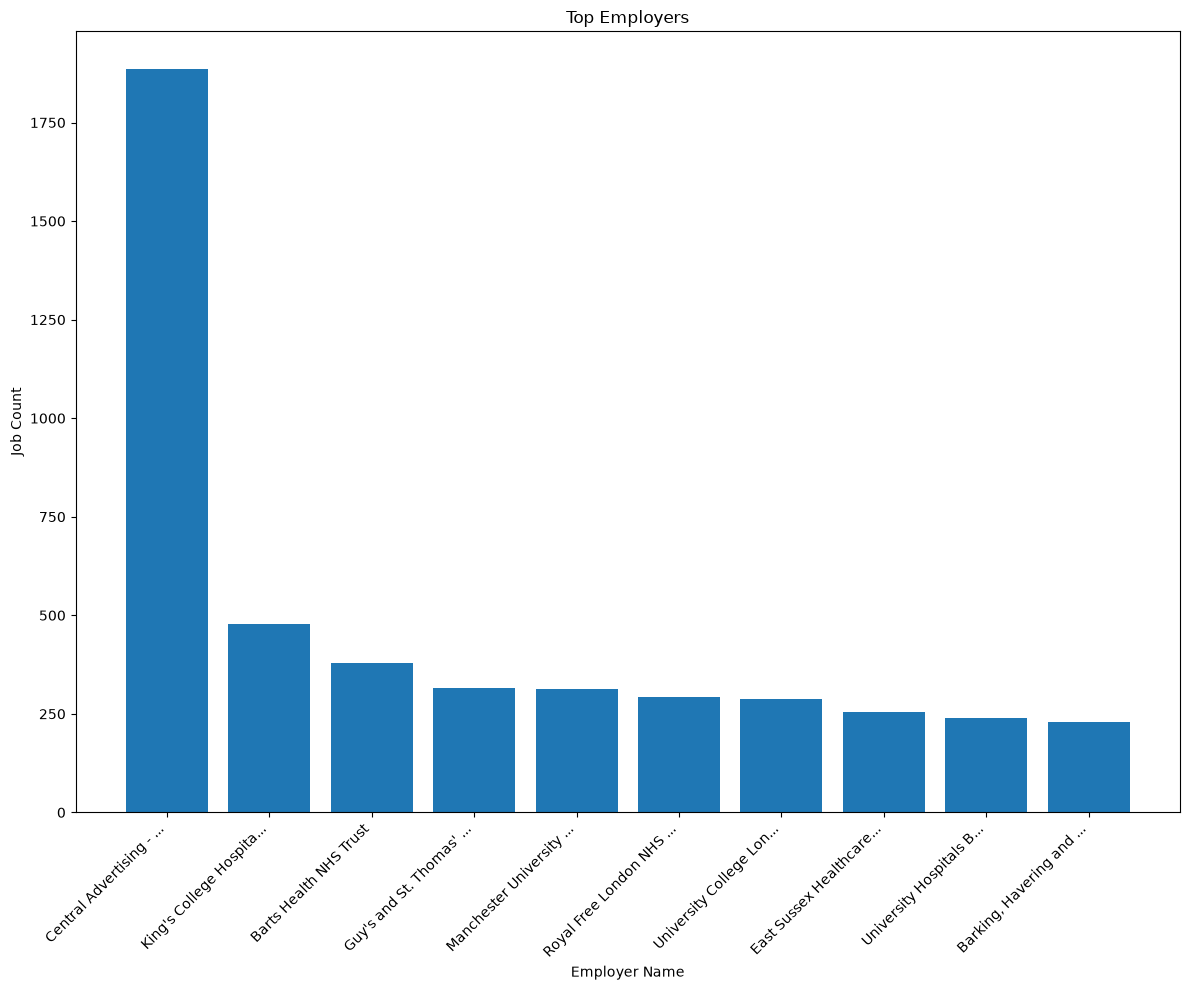

In [18]:
# Top Employers Bar Chart
max_label_length = 25

short_labels = [
    name if len(name) <= max_label_length else name[:max_label_length - 3] + "..."
    for name in df_employers["organisation"]
]

plt.figure(figsize=(12, 10))
plt.bar(short_labels, df_employers["jobs"])

plt.title("Top Employers")
plt.xlabel("Employer Name")
plt.ylabel("Job Count")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()


Shows the distribution of employers. Central advertising is clearly dominant, with trusts evenly distributed. One future avenue for AI layer will be to explore if jobs are duplicated between Central Advertising and individual trusts.

In [13]:
#Tiop Locations Bar Chart
df_locations = pd.DataFrame(top_locations())
df_locations.head()

,location,jobs
0,London,473
1,Birmingham,342
2,"Denmark Hill, London",326
3,Portsmouth,202
4,University College London Hospitals NHS Founda...,200


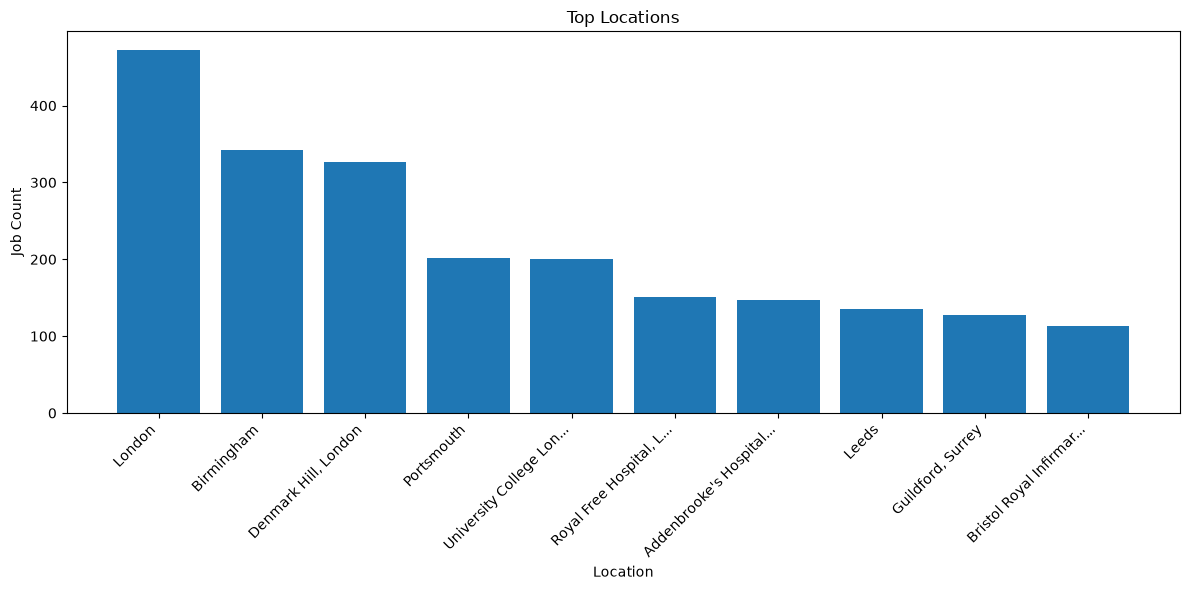

In [14]:
# Top Locations Bar Chart
max_label_length = 25

short_labels = [
    name if len(name) <= max_label_length else name[:max_label_length - 3] + "..."
    for name in df_locations["location"]
]

plt.figure(figsize=(12, 6))
plt.bar(short_labels, df_locations["jobs"])
plt.title("Top Locations")
plt.xlabel("Location")
plt.ylabel("Job Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Unsurprisingly the top locations for job postings are major cities, with London leading the way. However the chart also shows inconsistencies in the location field, with some showing locations and others specific hospitals.

In [19]:
#Contract Type Distribution Pie Chart
df_contracts = pd.DataFrame(jobs_by_contract_type())
df_contracts.head()

,contract_type,jobs
0,Permanent,11163
1,Fixed term,5260
2,Fixed term (12 months),1390
3,Fixed term (12 Months),727
4,Bank,680


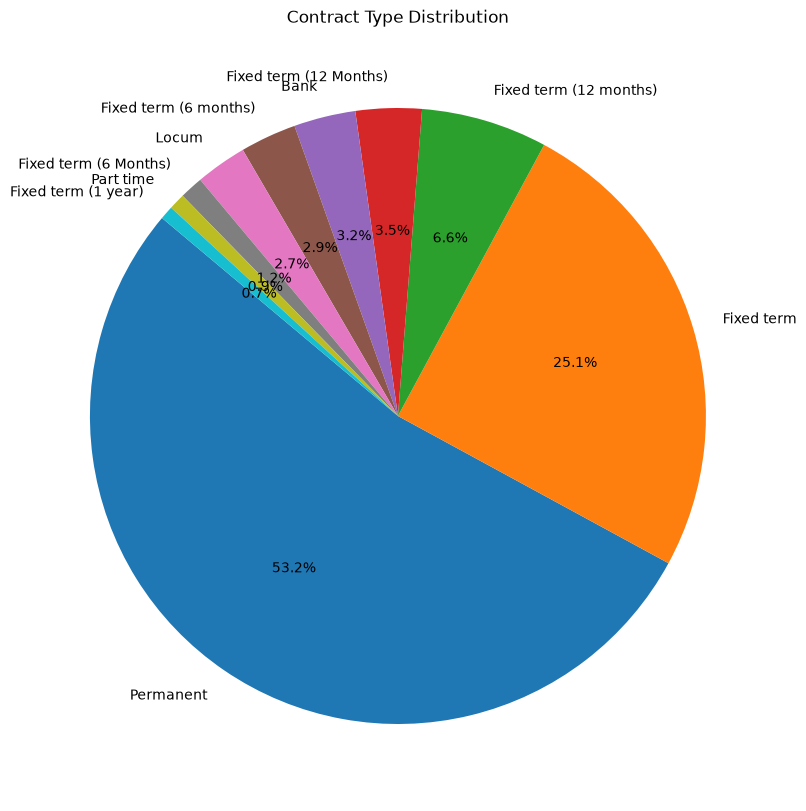

In [21]:
#contract Type Distribution Pie Chart
plt.figure(figsize=(10, 10))
plt.pie(
    df_contracts["jobs"],
    labels=df_contracts["contract_type"],
    autopct="%1.1f%%",
    startangle=140,
)
plt.title("Contract Type Distribution")
plt.show()

Shows a clear distribution, with Permanent contracts roughly half. Fixed term contracts are also very popular, though the majority are not of a specified length.